In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# Dataset MNIST

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
x_train = np.expand_dims(x_train, -1)  # [N,28,28,1]
x_test = np.expand_dims(x_test, -1)


In [3]:
x_train.shape

(60000, 28, 28, 1)

In [4]:
value_counts = Counter(y_train)
print(value_counts)

Counter({1: 6742, 7: 6265, 3: 6131, 2: 5958, 9: 5949, 0: 5923, 6: 5918, 8: 5851, 4: 5842, 5: 5421})


In [5]:
y_train

array([5, 0, 4, ..., 5, 6, 8], dtype=uint8)

In [27]:
i = 633
img = x_train[i]

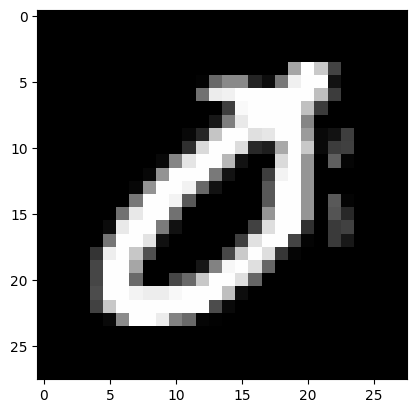

In [28]:
plt.imshow(img, cmap="gray")

In [31]:
y_train[i]

0

In [30]:
x_test.shape

(10000, 28, 28, 1)

# Operaciones en una CNN

## 1. Convolución

**Qué hace:**
Proceso donde un *filtro* (o *kernel*) pequeño —por ejemplo de tamaño 3×3— se desliza sobre la imagen y calcula una combinación ponderada (multiplicación y suma) de los píxeles bajo él.

**Ejemplo:**
Si tienes una imagen de 5×5 píxeles y aplicas un filtro 3×3, en cada posición el filtro toma una pequeña porción (3×3) de la imagen, multiplica cada valor por el peso correspondiente del filtro y suma todos esos valores → ese resultado es **un nuevo píxel** de la imagen salida (el *mapa de características*).

**Intuición:**
Cada filtro aprende a detectar un patrón visual: bordes, texturas, esquinas, etc.

---

## 2. Padding (relleno)

Cuando aplicas una convolución, la imagen se "encoge" (por ejemplo, una imagen 5×5 con filtro 3×3 produce una salida de 3×3).
**Padding** sirve para *rellenar los bordes* de la imagen con ceros (u otros valores), evitando esa reducción.

**Tipos comunes:**

* `"valid"` → sin padding, la salida se reduce.
* `"same"` → se añade el padding necesario para que la salida tenga el mismo tamaño que la entrada.

**Intuición:**
Padding evita perder información de los bordes y mantiene la resolución.

---

## 3. Stride (paso)

El **stride** indica *cuánto se mueve el filtro* en cada paso cuando se desliza sobre la imagen.

**Ejemplo:**

* Stride = 1 → el filtro se mueve 1 píxel a la vez (superposición máxima, salida grande).
* Stride = 2 → se mueve 2 píxeles (menos superposición, salida más pequeña).

**Intuición:**
Stride controla la *resolución espacial* de la salida. Cuanto mayor el stride, más compresión espacial (y menor coste computacional).

---

## 4. Pooling

**Pooling** reduce el tamaño espacial de los mapas de características, conservando la información más importante.

**Tipos comunes:**

* **MaxPooling:** toma el valor máximo dentro de una ventana (ej. 2×2).
* **AveragePooling:** toma el promedio.

**GlobalMaxPooling:** toma el máximo de *toda* la característica (por canal), reduciendo el mapa completo a un solo valor por canal.

**Intuición:**
Pooling resume regiones locales → hace la red más robusta a pequeñas traslaciones o distorsiones.

---

* La convolución detecta patrones.
* El padding mantiene dimensiones.
* El stride controla la velocidad de desplazamiento del filtro.
* El pooling reduce y resume la información.



# CNN model

In [32]:
x_train.shape

(60000, 28, 28, 1)

In [ ]:
[1,2,1,1,1,3,3]
[1,2,1,1,1,3,3]
[1,2,1,1,1,3,3]
[1,2,1,1,1,3,3]
[1,2,1,1,1,3,3]
[1,2,1,1,1,3,3]
[1,2,1,1,1,3,3]

In [ ]:
[3,3,2,2,2]
[2,2,2,2,2]
[2,2,2,2,2]
[2,2,2,2,2]
[2,2,2,2,2]

In [ ]:
[3,3,2,2,2, 2,2,2,2,2, 2,2,2,2,2, 2,2,2,2,2, 2,2,2,2,2] --> (1, 25)

In [60]:
inputs = tf.keras.Input(shape=(28,28,1))

x = tf.keras.layers.Conv2D(32, (5,5), activation="relu")(inputs)
x = tf.keras.layers.MaxPooling2D((2,2))(x)

x = tf.keras.layers.Flatten()(x)

x = tf.keras.layers.Dense(32, activation="relu")(x)
outputs = tf.keras.layers.Dense(10, activation="softmax")(x)

model = tf.keras.Model(inputs=inputs, outputs=outputs)

model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

# Training

In [61]:
model.fit(x_train, y_train, epochs=20, batch_size=128, validation_split=0.1)

Epoch 1/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.8266 - loss: 0.6150 - val_accuracy: 0.9743 - val_loss: 0.1048
Epoch 2/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9708 - loss: 0.1045 - val_accuracy: 0.9795 - val_loss: 0.0810
Epoch 3/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9808 - loss: 0.0667 - val_accuracy: 0.9858 - val_loss: 0.0567
Epoch 4/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9841 - loss: 0.0542 - val_accuracy: 0.9855 - val_loss: 0.0539
Epoch 5/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9873 - loss: 0.0420 - val_accuracy: 0.9878 - val_loss: 0.0466
Epoch 6/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9892 - loss: 0.0357 - val_accuracy: 0.9892 - val_loss: 0.0432
Epoch 7/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9909 - loss: 0.0295 - val_accuracy: 0.9863 - val_loss: 0.0486
Epoch 8/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9916 - loss: 0.0269 - val_accura

In [62]:
i = 13
img = x_test[i:(i+1)]
img.shape

(1, 28, 28, 1)

In [63]:
model.predict(img)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 494ms/step


array([[1.0000000e+00, 1.0402082e-23, 4.7536157e-17, 1.7327937e-17,
        3.1593458e-28, 1.7212025e-13, 2.3356653e-12, 1.9967251e-13,
        1.1717746e-12, 1.1290925e-15]], dtype=float32)

In [64]:
np.argmax(model.predict(img))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step


0

In [65]:
y_test[i]

0

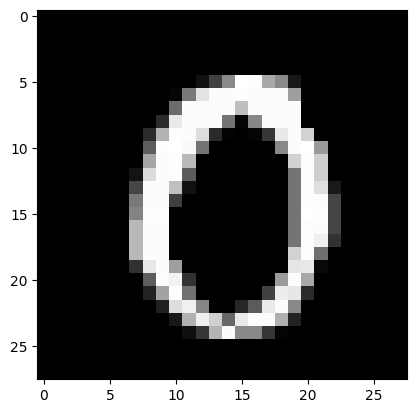

In [66]:
plt.imshow(img[i], cmap="gray")

# Extraemos filtros de la primera capa

In [67]:
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 32)     │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │       147,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 445,952 (1.70 MB)

 Trainable params: 148,650 (580.66 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 297,302 (1.13 MB)

In [68]:
l1 = model.layers[1].get_weights()

In [69]:
l1[0].shape

(5, 5, 1, 32)

In [70]:
filters, biases = model.layers[1].get_weights()
print("Forma de los filtros:", filters.shape)

Forma de los filtros: (5, 5, 1, 32)


In [71]:
filters[:,:, 0, 1]

array([[ 0.18630275,  0.24429153,  0.15026778, -0.13098043, -0.21770388],
       [ 0.02776683, -0.04483399, -0.23782112, -0.1544556 ,  0.0808496 ],
       [-0.21529464, -0.34698814, -0.00473773,  0.21891439,  0.21179818],
       [-0.18509111,  0.03665091,  0.17744052,  0.14898652, -0.07385759],
       [ 0.07875028,  0.1942316 , -0.07034066, -0.11503615, -0.03097027]],
      dtype=float32)

# Visualizamos filtros

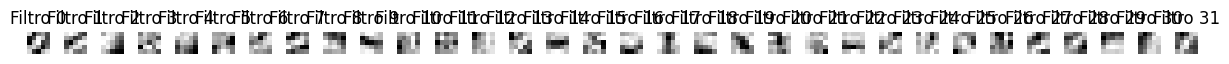

In [72]:
plt.figure(figsize=(12,6))
for i in range(filters.shape[-1]):  # cada filtro
    f = filters[:, :, 0, i]

    # Plot filtro
    plt.subplot(2, filters.shape[-1], i+1)
    plt.imshow(f, cmap="gray")
    plt.axis("off")
    plt.title(f"Filtro {i}")

plt.tight_layout()
plt.show()


# Ejemplo de una convolución con una imagen

In [73]:
img = x_test[0:1]

In [74]:
first_layer = model.layers[1]
first_layer.output

<KerasTensor shape=(None, 24, 24, 32), dtype=float32, sparse=False, ragged=False, name=keras_tensor_13>

In [75]:
activation_model = tf.keras.Model(inputs=model.input,
                                  outputs=first_layer.output)

activations = activation_model.predict(img)

activations.shape

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 351ms/step


(1, 24, 24, 32)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
Forma de la activación: (1, 24, 24, 32)


ValueError: num must be an integer with 1 <= num <= 8, not 9

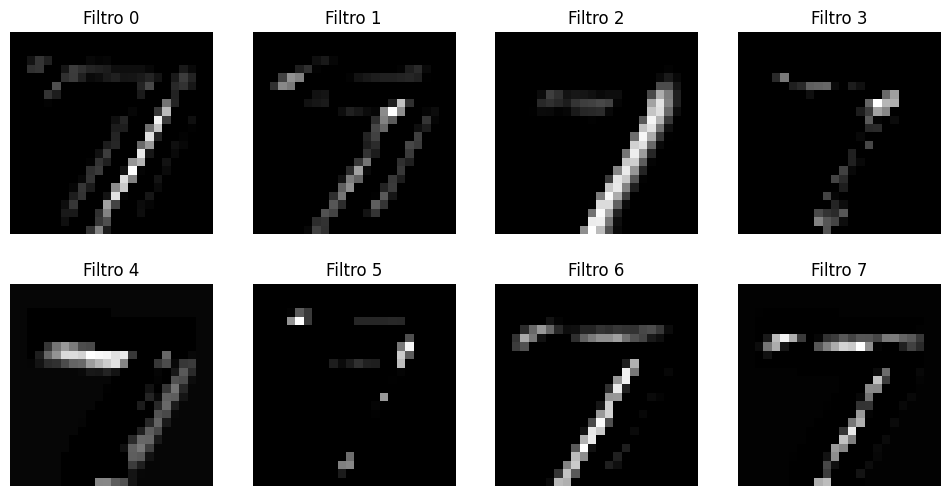

In [76]:
activations = activation_model.predict(img)

print("Forma de la activación:", activations.shape)

plt.figure(figsize=(12,6))
for i in range(activations.shape[-1]):
    plt.subplot(2, 4, i+1)
    plt.imshow(activations[0,:,:,i], cmap="gray")
    plt.axis("off")
    plt.title(f"Filtro {i}")

plt.tight_layout()
plt.show()

In [ ]:
activations.shape

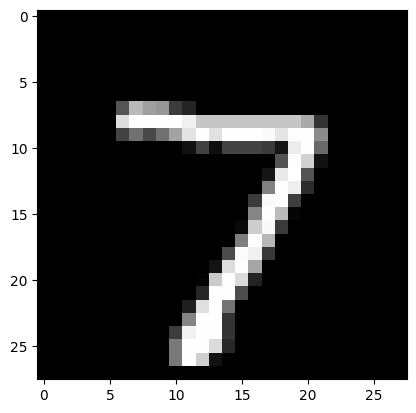

In [77]:
plt.imshow(img[0], cmap="gray")